In [45]:
%pip install codecarbon


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/516.7 kB ? eta -:--:--
   -------- ------------------------------- 112.6/516.7 kB 3.3 MB/s eta 0:00:01
   ---------------------------------------  512.0/516.7 kB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 516.7/516.7 kB 6.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ----------------- ---------------------- 0.7/1.6 MB 22.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.2/1.6 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 13.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/92.5 kB ? eta -:--:--
   ---------------------------------------- 92.5/92.5 kB 5.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/44.4 kB ? eta -:--:--
   -------------------------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer



In [6]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train['user_id'] = train['user_id'].str[1:].astype(int)
test['user_id'] = test['user_id'].str[1:].astype(int)

train = train.dropna()
test = test.dropna()

train = train.drop_duplicates()
test = test.drop_duplicates()


In [7]:
vectorizer = TfidfVectorizer(max_features=5000)
text_features = vectorizer.fit_transform(train['text'])
text_features_test = vectorizer.transform(test['text'])
from scipy.sparse import hstack

X_train = hstack([train[['user_id']], text_features])
X_test = hstack([test[['user_id']], text_features_test])
y_train = train['label']
y_test = test['label']






In [8]:
from sklearn.linear_model import LogisticRegression

from codecarbon import EmissionsTracker

tracker = EmissionsTracker()
tracker.start()
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
tracker.stop()




[codecarbon INFO @ 12:02:51] [setup] RAM Tracking...
[codecarbon INFO @ 12:02:51] [setup] CPU Tracking...
[codecarbon WARNING @ 12:02:51] No CPU tracking mode found. Falling back on CPU constant mode. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 12:02:53] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 12:02:53] [setup] GPU Tracking...
[codecarbon INFO @ 12:02:53] No GPU found.
[codecarbon INFO @ 12:02:53] >>> Tracker's metadata:
[codecarbon INFO @ 12:02:53]   Platform system: Windows-10-10.0.22631-SP0
[codecarbon INFO @ 12:02:53]   Python version: 3.11.2
[codecarbon INFO @ 12:02:53]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 12:02:53]   Available RAM : 13.866 GB
[codecarbon INFO @ 12:02:53]   CPU count: 12
[codecarbon INFO @ 12:02:53]   CPU model: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon INFO @ 12:02:53]   GPU count: None
[codecarbon INFO @ 12:02:53]   GPU model: None
[codeca

2.3936944322804885e-05

In [14]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# auc

y_pred = lr.predict_proba(X_test)[:, 1]
test['pred'] = y_pred
auc = roc_auc_score(y_test, y_pred)

print(f"AUC-ROC Score: {auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred > 0.2):.4f}")
print(classification_report(y_test, y_pred > 0.2))





AUC-ROC Score: 0.7300
Accuracy: 0.6092
              precision    recall  f1-score   support

           0       0.79      0.52      0.63   2367799
           1       0.48      0.77      0.59   1369457

    accuracy                           0.61   3737256
   macro avg       0.64      0.64      0.61   3737256
weighted avg       0.68      0.61      0.61   3737256



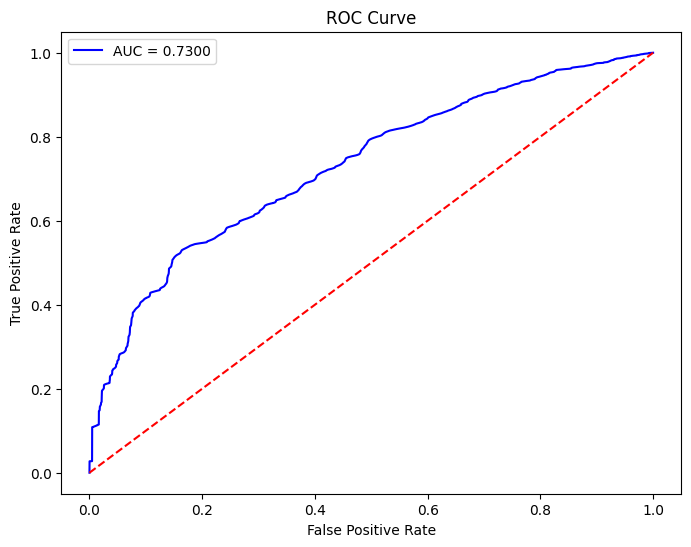

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve points
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
df = test.copy()


import numpy as np
from sklearn.metrics import roc_auc_score

# --- Metric Functions ---
def dcg_score(y_true, y_score, k=10):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order[:k])
    gains = 2 ** y_true - 1
    discounts = np.log2(np.arange(len(y_true)) + 2)
    return np.sum(gains / discounts)

def ndcg_score_custom(y_true, y_score, k=10):
    best = dcg_score(y_true, y_true, k)
    actual = dcg_score(y_true, y_score, k)
    return actual / best if best > 0 else 0

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order)
    rr_score = y_true / (np.arange(len(y_true)) + 1)
    return np.sum(rr_score) / np.sum(y_true) if np.sum(y_true) > 0 else 0
def reciprocal_rank(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order)
    # top 5
    for i in range(5):
        if y_true[i] == 1:
            return 1/(i+1)
    return 0


In [16]:
def compute_metrics(df):
    aucs, mrrs,rrs, ndcg5s, ndcg10s = [], [], [], [], []

    for user_id, group in df.groupby('user_id'):
        y_true = group['label'].values
        y_score = group['pred'].values

        if len(np.unique(y_true)) < 2:
            # AUC needs both classes
            continue

        auc = roc_auc_score(y_true, y_score)
        mrr = mrr_score(y_true, y_score)
        rr = reciprocal_rank(y_true, y_score)
        ndcg5 = ndcg_score_custom(y_true, y_score, k=5)
        ndcg10 = ndcg_score_custom(y_true, y_score, k=10)

        aucs.append(auc)
        mrrs.append(mrr)
        rrs.append(rr)
        ndcg5s.append(ndcg5)
        ndcg10s.append(ndcg10)

    # Average across all users
    return {
        'AUC': np.mean(aucs),
        'MRR': np.mean(mrrs),
        'RR': np.mean(rrs),
        'nDCG@5': np.mean(ndcg5s),
        'nDCG@10': np.mean(ndcg10s)
    }


metrics = compute_metrics(df)
print(metrics)



{'AUC': 0.7076033880786413, 'MRR': 0.16380275876525674, 'RR': 0.8501236666666665, 'nDCG@5': 0.7243120763783252, 'nDCG@10': 0.7136583197473613}


In [ ]:
# {'AUC': 0.659532095694196, 'MRR': 0.14682727591129965, 'nDCG@5': 0.6215019707789203, 'nDCG@10': 0.6300287186876513}

In [13]:
# explore label distribution
test['label'].value_counts(normalize=True)

user_counts = (
    test.groupby(['user_id', 'label'])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: 'num_0s', 1: 'num_1s'})
)

avg_per_label = user_counts.mean()
print(f"Average number of 0s per user: {avg_per_label['num_0s']:.2f}")
print(f"Average number of 1s per user: {avg_per_label['num_1s']:.2f}")

# average number of rows per user
avg_per_user = user_counts.sum(axis=1).mean()
print(f"Average number of rows per user: {avg_per_user:.2f}")


Average number of 0s per user: 47.36
Average number of 1s per user: 27.39
Average number of rows per user: 74.75


In [ ]:
import numpy as np

# True relevance labels (1 = relevant, 0 = not relevant)
y_true = np.array([0, 0, 1, 0, 1])

# Predicted scores from model (higher = more confident)
y_score = np.array([0.1, 0.4, 0.35, 0.8, 0.2])

# Call the function

rr = reciprocal_rank(y_true, y_score)
print("Reciprocal Rank:", rr)


[3 1 2 4 0]
[0 0 1 1 0]
0 0
1 0
2 1
Reciprocal Rank: 0.3333333333333333
